In [23]:
import matplotlib.pyplot as plt 
import numpy as np 
import csv

In [24]:
alphas = [0.001,0.01,0.1,0.5,0.9,0.99,0.999]

L1error = {}
for alpha in alphas: 
    L1error[alpha] = {}
    with open("data/RA_CO/L1error_HIGH_ACCURACY/L1error"+str(alpha)+".csv", mode="r") as file: 
        csvreader = csv.reader(file)
        for row in csvreader:
            if row[0] != 'first': 
                tol = float(row[0])
                L1error[alpha][tol] = float(row[1])

m = {} 
m[0.001] = [4,13,23,33,43,52,61,71,80,89,98] 
m[0.01]  = [6,15,25,34,44,53,64,72,81,91,99] 
m[0.1]   = [8,18,28,37,47,56,65,75,84,93,101] 
m[0.5]   = [11,21,31,40,50,59,68,78,87,95,103] 
m[0.9]   = [13,22,32,42,51,61,70,79,88,96,104] 
m[0.99]  = [11,21,30,41,50,59,68,77,86,95,103] 
m[0.999] = [9,19,29,38,48,57,67,75,84,93,101] 

tolerances = [1e-5,1e-10,1e-15,1e-20,1e-25,1e-30,1e-35,1e-40,1e-45,1e-50,1e-55]


In [25]:
cmap = plt.get_cmap("inferno_r")

colors = {}
colors[0.001] = cmap(1./8)
colors[0.01]  = cmap(2./8)
colors[0.1]   = cmap(3./8)
colors[0.5]   = cmap(4./8)
colors[0.9]   = cmap(5./8)
colors[0.99]  = cmap(6./8)
colors[0.999] = cmap(7./8)

markers = {}
markers[0.001] = "o"
markers[0.01]  = "d"
markers[0.1]   = "s"
markers[0.5]   = "p"
markers[0.9]   = "v"
markers[0.99]  = "h"
markers[0.999] = "D"


/tmp/ipykernel_39590/3298467957.py:50: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  fig.savefig("Images/CO_combined.pdf", bbox_inches="tight")
/home/jonas/.local/lib/python3.8/site-packages/IPython/core/events.py:89: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  func(*args, **kwargs)
/home/jonas/.local/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  fig.canvas.print_figure(bytes_io, **kw)


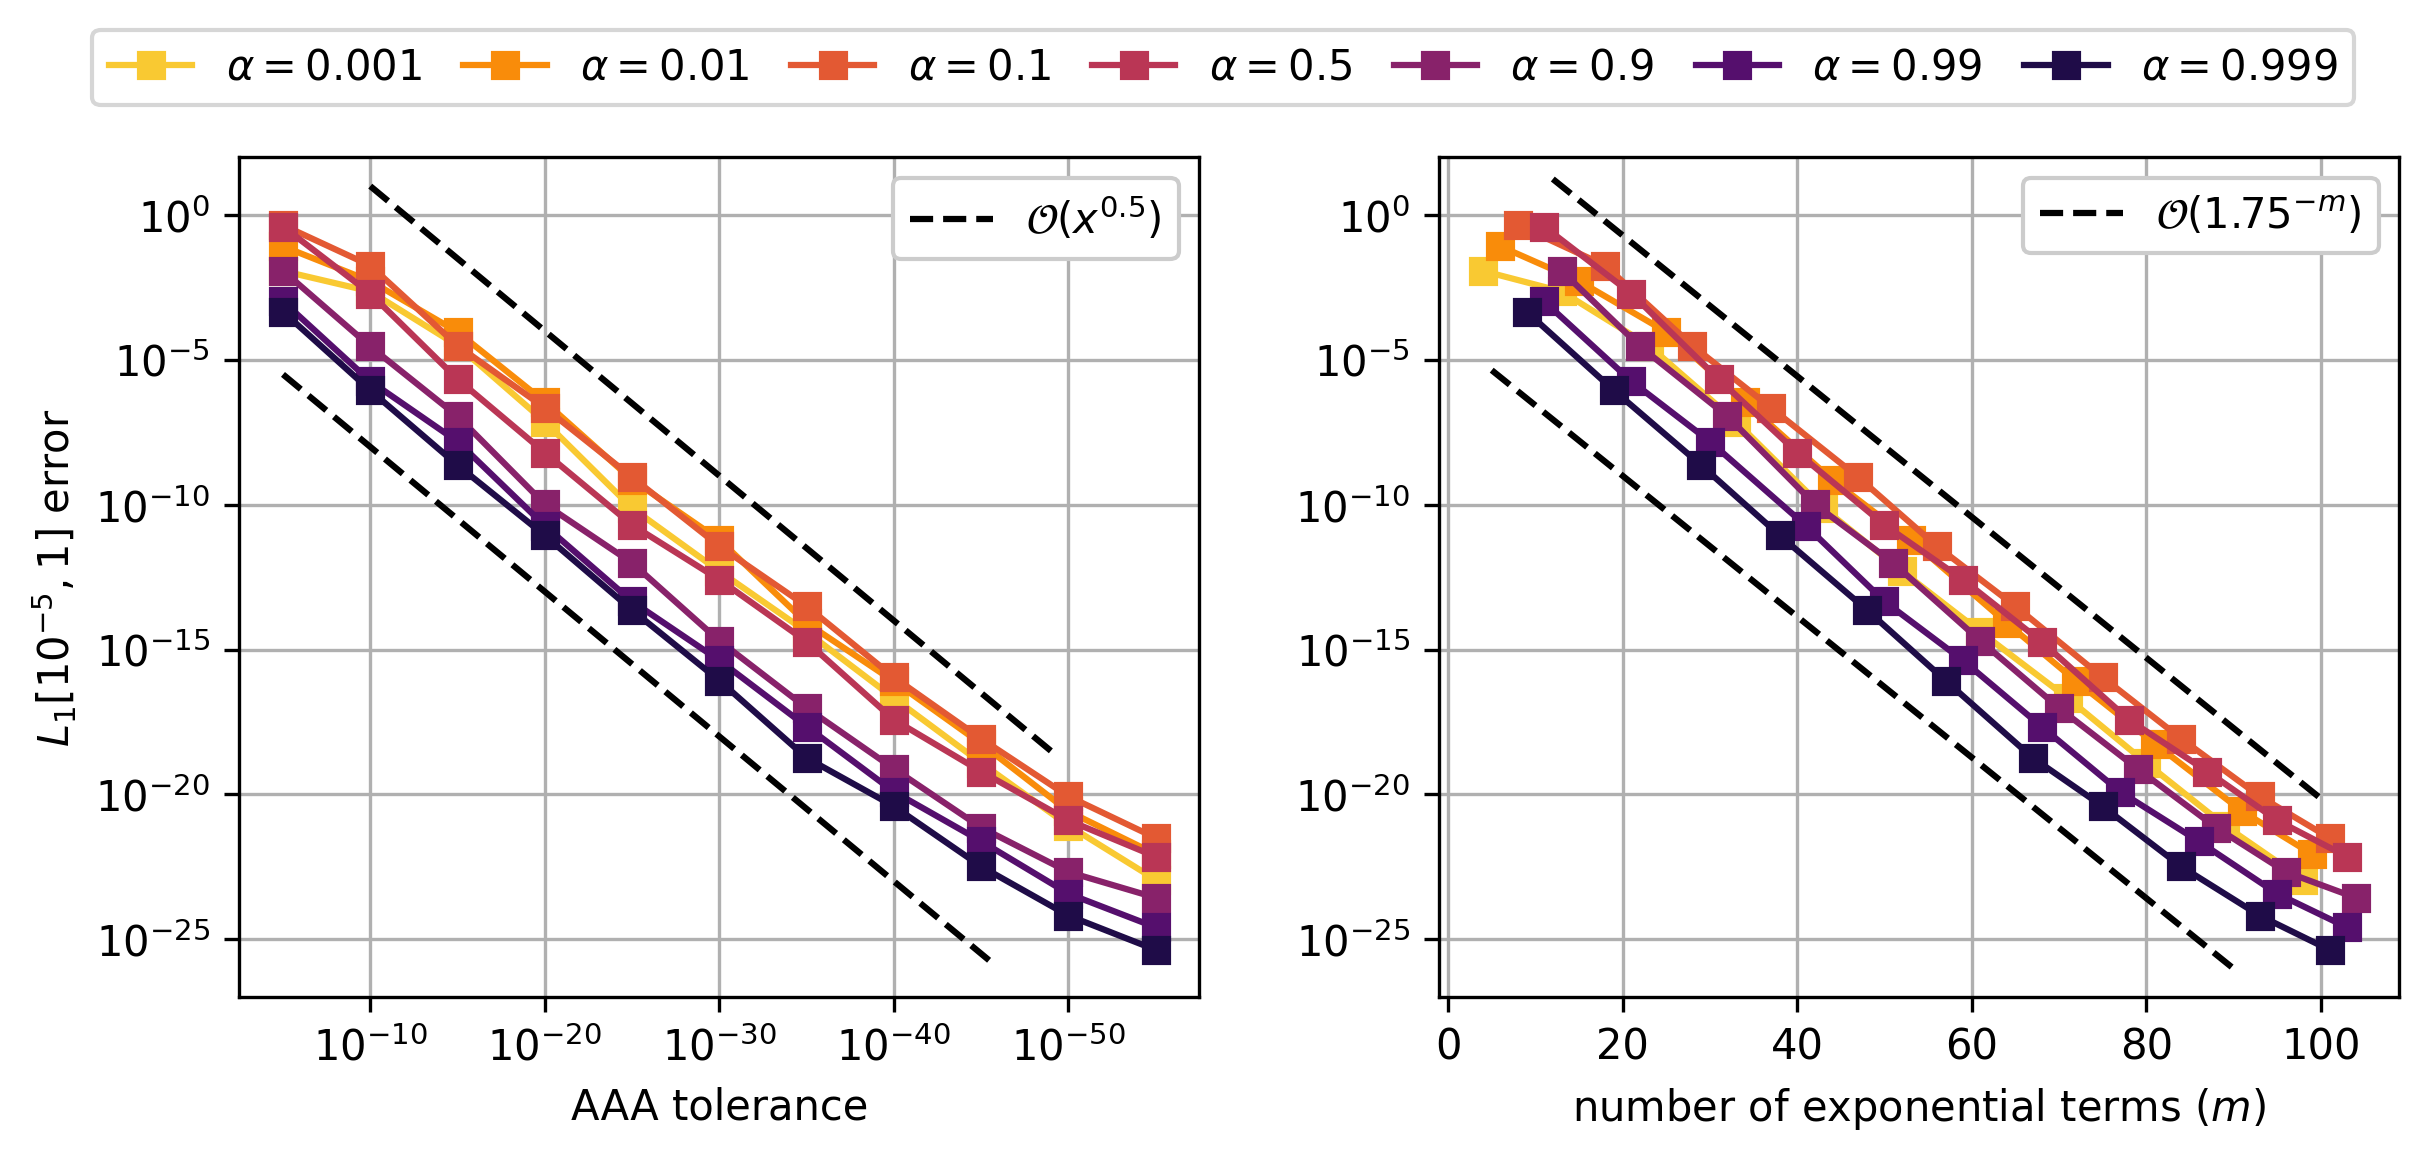

In [26]:
fig = plt.figure(figsize=(8,4), dpi = 300, constrained_layout=True)
ax1 = fig.add_axes([0.05, 0.75, 0.4, 0.7])
ax2 = fig.add_axes([0.55, 0.75, 0.4, 0.7])    

# heuristic lines 
x = 10**np.linspace(-10,-49,100)
ax1.plot(x,1e6 * x**0.5, zorder = 15, linestyle="--", color="black")
x = 10**np.linspace(-5,-45.5,100)
ax1.plot(x,1e-3 * x**0.5, zorder = 15, linestyle="--", color="black", label=r"$\mathcal{O}(x^{0.5})$")

x = np.linspace(12,100,81)
ax2.plot(x,2e-1 * 1.75**20 * 1.75**-x, zorder = 15, linestyle="--", color="black")
x = np.linspace(5,90,81)
ax2.plot(x,1e-9 * 1.75**20 * 1.75**-x, zorder = 15, linestyle="--", color="black", label=r"$\mathcal{O}(1.75^{-m})$")

ax1.legend(framealpha=1)
ax2.legend(framealpha=1)

for alpha in alphas: 
    tols = []
    errors = []
    for tol in L1error[alpha]:
        tols.append(tol)
        errors.append(L1error[alpha][tol])
    tols, errors =  (list(t) for t in zip(*sorted(zip(tols, errors))))
    ax1.plot(tols, errors, color = colors[alpha], label = r"$\alpha=$"+str(alpha), zorder=10, marker="s")
    ax2.plot(m[alpha], errors[::-1], color = colors[alpha], label = r"$\alpha=$"+str(alpha), zorder=10, marker="s")
        
# axis 
ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.invert_xaxis()
ax1.set_xticks([1e-10,1e-20,1e-30, 1e-40, 1e-50])
ax1.set_yticks([1e-0, 1e-5,1e-10,1e-15, 1e-20, 1e-25])
ax1.set_ylim([1e-27, 1e2])

ax1.grid('on')
ax1.set_xlabel("AAA tolerance")
ax1.set_ylabel(r"$L_1[10^{-5},1]$ error")

ax2.set_yscale("log")
ax2.set_yticks([1e-0, 1e-5,1e-10,1e-15, 1e-20, 1e-25])
ax2.set_ylim([1e-27, 1e2])
ax2.grid('on')
ax2.set_xlabel(r"number of exponential terms $(m)$")

h1, l1 = ax1.get_legend_handles_labels()

fig.legend(handles=h1[1:], labels=l1[1:], bbox_to_anchor=(0.46, 1.525), loc="center", ncol=7, columnspacing=1.0, borderaxespad=0.3)
fig.savefig("Images/CO_combined.pdf", bbox_inches="tight")